# Linear Regression - Practice

We will apply what you learned about linear regression for a new data set. 

The `Data` folder contains a `csv`-file containing information about CO$_2$ vehicle emissions for vehicles in Canada. 

You can now practice what you learned by 

1. loading the dataset into pandas
2. performing exploratory data analysis to understand
    - what the columns are?
    - descriptive statistics of numeric and text columns (e.g. value counts, mean, std)
3. make plots and calculate correlation coefficients to find linear correlations in the data
4. apply simple linear regression 
5. apply multiple linear regression 
6. explore the impact of the car type (a discrete variable) on CO$_2$ emissions

**Happy working!**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import statsmodels.formula.api as smf 
import statsmodels.api as sm

In [5]:
df_CO2 = pd.read_csv('../../W12_Statistical_Models/Data/CO2 Emissions_Canada.csv',
                          sep = ',',
                          na_values='NA')
df_CO2

df_CO2.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [6]:
df_CO2.describe()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,27.481652,250.584699
std,1.354170,1.828307,3.500274,2.224456,2.892506,7.231879,58.512679
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,288.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


In [8]:
df_Cadillac = df_CO2.loc[df_CO2.Make == 'CADILLAC']
df_Cadillac

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
156,CADILLAC,ATS,COMPACT,2.0,4,AS6,Z,11.3,7.5,9.6,29,221
157,CADILLAC,ATS,COMPACT,2.0,4,M6,Z,12.1,7.9,10.2,28,235
158,CADILLAC,ATS,COMPACT,2.5,4,AS6,X,10.5,7.2,9.0,31,207
159,CADILLAC,ATS,COMPACT,3.6,6,AS6,X,12.8,8.5,10.9,26,251
160,CADILLAC,ATS AWD,COMPACT,2.0,4,AS6,Z,11.8,8.1,10.1,28,232
...,...,...,...,...,...,...,...,...,...,...,...,...
6668,CADILLAC,XT4 AWD,SUV - SMALL,2.0,4,AS9,Z,10.9,8.2,9.7,29,227
6669,CADILLAC,XT5,SUV - SMALL,2.0,4,AS9,Z,11.0,8.3,9.8,29,227
6670,CADILLAC,XT5 AWD,SUV - SMALL,2.0,4,AS9,Z,11.2,8.9,10.1,28,235
6671,CADILLAC,XT5 AWD,SUV - SMALL,3.6,6,AS9,X,13.4,9.4,11.6,24,270


In [11]:
df_CO2.Make.unique()

array(['ACURA', 'ALFA ROMEO', 'ASTON MARTIN', 'AUDI', 'BENTLEY', 'BMW',
       'BUICK', 'CADILLAC', 'CHEVROLET', 'CHRYSLER', 'DODGE', 'FIAT',
       'FORD', 'GMC', 'HONDA', 'HYUNDAI', 'INFINITI', 'JAGUAR', 'JEEP',
       'KIA', 'LAMBORGHINI', 'LAND ROVER', 'LEXUS', 'LINCOLN', 'MASERATI',
       'MAZDA', 'MERCEDES-BENZ', 'MINI', 'MITSUBISHI', 'NISSAN',
       'PORSCHE', 'RAM', 'ROLLS-ROYCE', 'SCION', 'SMART', 'SRT', 'SUBARU',
       'TOYOTA', 'VOLKSWAGEN', 'VOLVO', 'GENESIS', 'BUGATTI'],
      dtype=object)

<Axes: xlabel='Fuel Consumption City (L/100 km)', ylabel='CO2 Emissions(g/km)'>

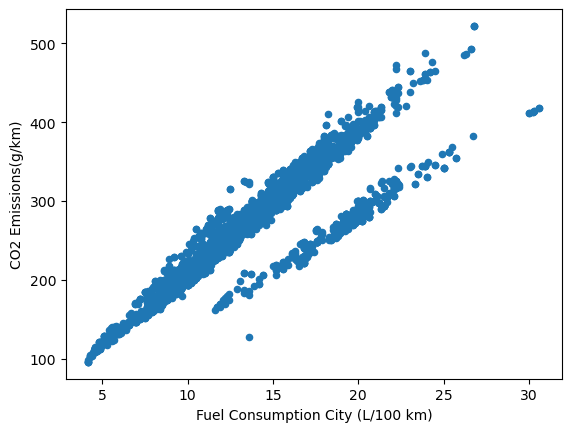

In [14]:
df_CO2.plot(kind = 'scatter', x='Fuel Consumption City (L/100 km)',y='CO2 Emissions(g/km)')

<Axes: xlabel='Engine Size(L)', ylabel='CO2 Emissions(g/km)'>

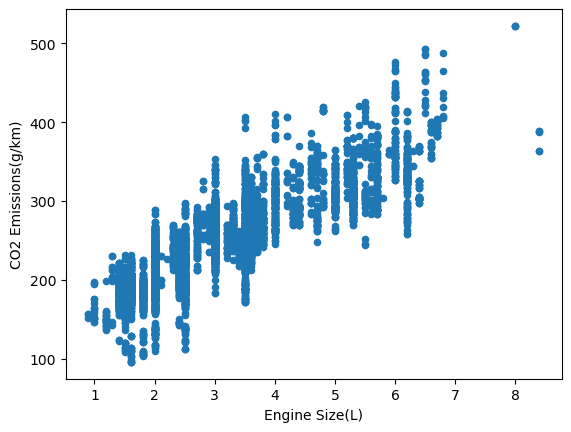

In [15]:
df_CO2.plot(kind = 'scatter', x='Engine Size(L)',y='CO2 Emissions(g/km)')

In [16]:
numeric_cols = ['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)', 'CO2 Emissions(g/km)']
df_Cadillac[numeric_cols].corr()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),CO2 Emissions(g/km)
Engine Size(L),1.000000,0.954544,0.851588,0.893470
Cylinders,0.954544,1.000000,0.839611,0.886779
Fuel Consumption City (L/100 km),0.851588,0.839611,1.000000,0.935760
CO2 Emissions(g/km),0.893470,0.886779,0.935760,1.000000


In [17]:
import scipy.stats as stats 

df_without_nan = df_Cadillac.copy().dropna()
x = df_without_nan['Engine Size(L)']
y = df_without_nan['CO2 Emissions(g/km)']

res = stats.pearsonr(x, y)
print(res)
print(res.confidence_interval(confidence_level=0.9))

PearsonRResult(statistic=np.float64(0.8934696510637886), pvalue=np.float64(4.187767856164639e-56))
ConfidenceInterval(low=np.float64(0.8634508426834704), high=np.float64(0.9171824528282865))


In [18]:
df_without_nan[['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)', 'CO2 Emissions(g/km)']].corr()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),CO2 Emissions(g/km)
Engine Size(L),1.000000,0.954544,0.851588,0.893470
Cylinders,0.954544,1.000000,0.839611,0.886779
Fuel Consumption City (L/100 km),0.851588,0.839611,1.000000,0.935760
CO2 Emissions(g/km),0.893470,0.886779,0.935760,1.000000


In [19]:
x = df_without_nan['Engine Size(L)']
y = df_without_nan['CO2 Emissions(g/km)']

res = stats.linregress(x,y,nan_policy='omit')
print(res)

LinregressResult(slope=np.float64(27.849508808626307), intercept=np.float64(168.5926648063291), rvalue=np.float64(0.893469651063788), pvalue=np.float64(4.187767856166844e-56), stderr=np.float64(1.1208339686265079), intercept_stderr=np.float64(4.178163164713529))


In [20]:
Engine_Size_estimated = df_without_nan['CO2 Emissions(g/km)']*res.slope + res.intercept
Engine_Size_estimated

156     6323.334112
157     6713.227235
158     5933.440988
159     7158.819376
160     6629.678708
           ...     
6668    6490.431164
6669    6490.431164
6670    6713.227235
6671    7687.960043
6672    7882.906605
Name: CO2 Emissions(g/km), Length: 158, dtype: float64

Text(32, 21, 'y = 27.85x + 168.59\n$R^2$ = 0.80')

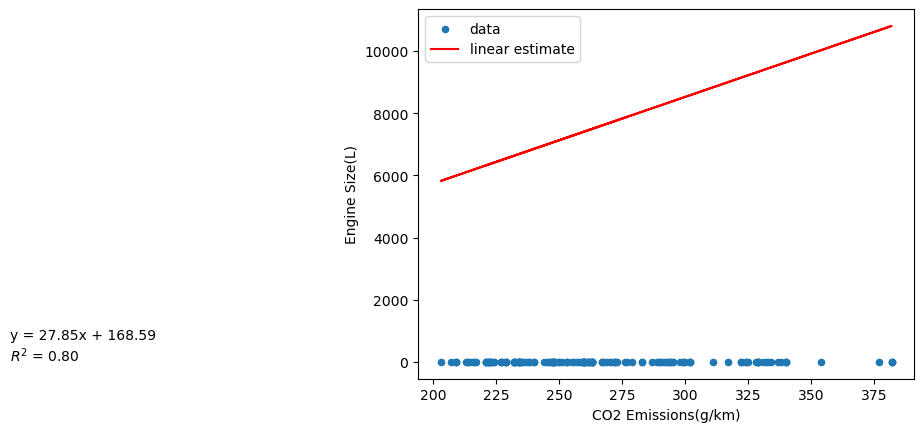

In [21]:
import matplotlib.pyplot as plt
df_Cadillac.plot(kind = 'scatter', x='CO2 Emissions(g/km)',y='Engine Size(L)')
plt.plot( df_without_nan['CO2 Emissions(g/km)'], Engine_Size_estimated, 'r')
plt.legend(['data', 'linear estimate'])
plt.text(32,21, f'y = {res.slope:.2f}x + {res.intercept:.2f}\n$R^2$ = {(res.rvalue)**2:.2f}')

<Axes: ylabel='Frequency'>

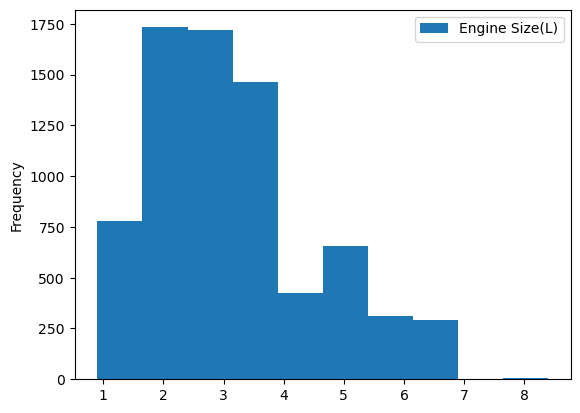

In [32]:
df_CO2.plot(kind= 'hist', y='Engine Size(L)')

In [38]:
import pandas as pd
df_CO2.groupby('Make')['CO2 Emissions(g/km)'].mean()


Make
ACURA            223.652778
ALFA ROMEO       224.900000
ASTON MARTIN     339.617021
AUDI             250.846154
BENTLEY          362.934783
BMW              254.007590
BUGATTI          522.000000
BUICK            233.058252
CADILLAC         265.854430
CHEVROLET        264.346939
CHRYSLER         246.170455
DODGE            276.361789
FIAT             192.246575
FORD             260.988854
GENESIS          284.840000
GMC              299.917683
HONDA            190.219626
HYUNDAI          208.871429
INFINITI         254.064815
JAGUAR           267.987500
JEEP             250.342629
KIA              214.294372
LAMBORGHINI      400.780488
LAND ROVER       287.647059
LEXUS            241.112360
LINCOLN          267.302083
MASERATI         318.147541
MAZDA            193.672222
MERCEDES-BENZ    277.386635
MINI             196.588235
MITSUBISHI       200.505263
NISSAN           236.864865
PORSCHE          258.941489
RAM              292.402062
ROLLS-ROYCE      388.480000
SCION          